In [1]:
from jobflow import JobStore, run_locally
from maggma.stores import MemoryStore
from pymatgen.core import Structure
from fireworks import LaunchPad
from jobflow.managers.fireworks import flow_to_workflow
from atomate2.vasp.flows.qha import QhaMaker

from atomate2.forcefields.jobs import ForceFieldRelaxMaker
from atomate2.forcefields.jobs import ForceFieldStaticMaker
from atomate2.forcefields.flows.phonons import PhononMaker

si_structure = Structure.from_file("Si.cif")


bulk_relax_maker = ForceFieldRelaxMaker(force_field_name="MACE_MPA_0", relax_cell=True, relax_kwargs={"fmax": 0.0001}, calculator_kwargs={"model_type": "MACE"})
bulk_relax_maker_constant_volume = ForceFieldRelaxMaker(force_field_name="MACE_MPA_0", relax_cell=False,  relax_kwargs={"fmax": 0.0001}, calculator_kwargs={"model_type": "MACE"})

phonon_displacement_maker = ForceFieldStaticMaker(force_field_name="MACE_MPA_0",calculator_kwargs={"model_type": "MACE"})
phonon_displacement_maker.name = "mace phonon static"
flow = QhaMaker(
    initial_relax_maker=bulk_relax_maker,
    eos_relax_maker=bulk_relax_maker_constant_volume,
    min_length=10,
    phonon_maker=PhononMaker(
        generate_frequencies_eigenvectors_kwargs={
            "tmin": 0,
            "tmax": 500,
            "tstep": 10,
        },
        bulk_relax_maker=None,
        born_maker=None,
        static_energy_maker=phonon_displacement_maker,
        phonon_displacement_maker=phonon_displacement_maker,
    ),
    linear_strain=(-0.1, 0.1),
    number_of_frames=10,
    pressure=None,
    t_max=None,
    ignore_imaginary_modes=False,
    skip_analysis=False,
    eos_type="vinet",
).make(structure=si_structure)



/home/sjonathan/anaconda3/envs/fireworks_mp/lib/python3.11/site-packages/pymatgen/core/structure.py:3175: EncodingWarning: We strongly encourage explicit `encoding`, and we would use UTF-8 by default as per PEP 686
  with zopen(filename, mode="rt", errors="replace") as file:


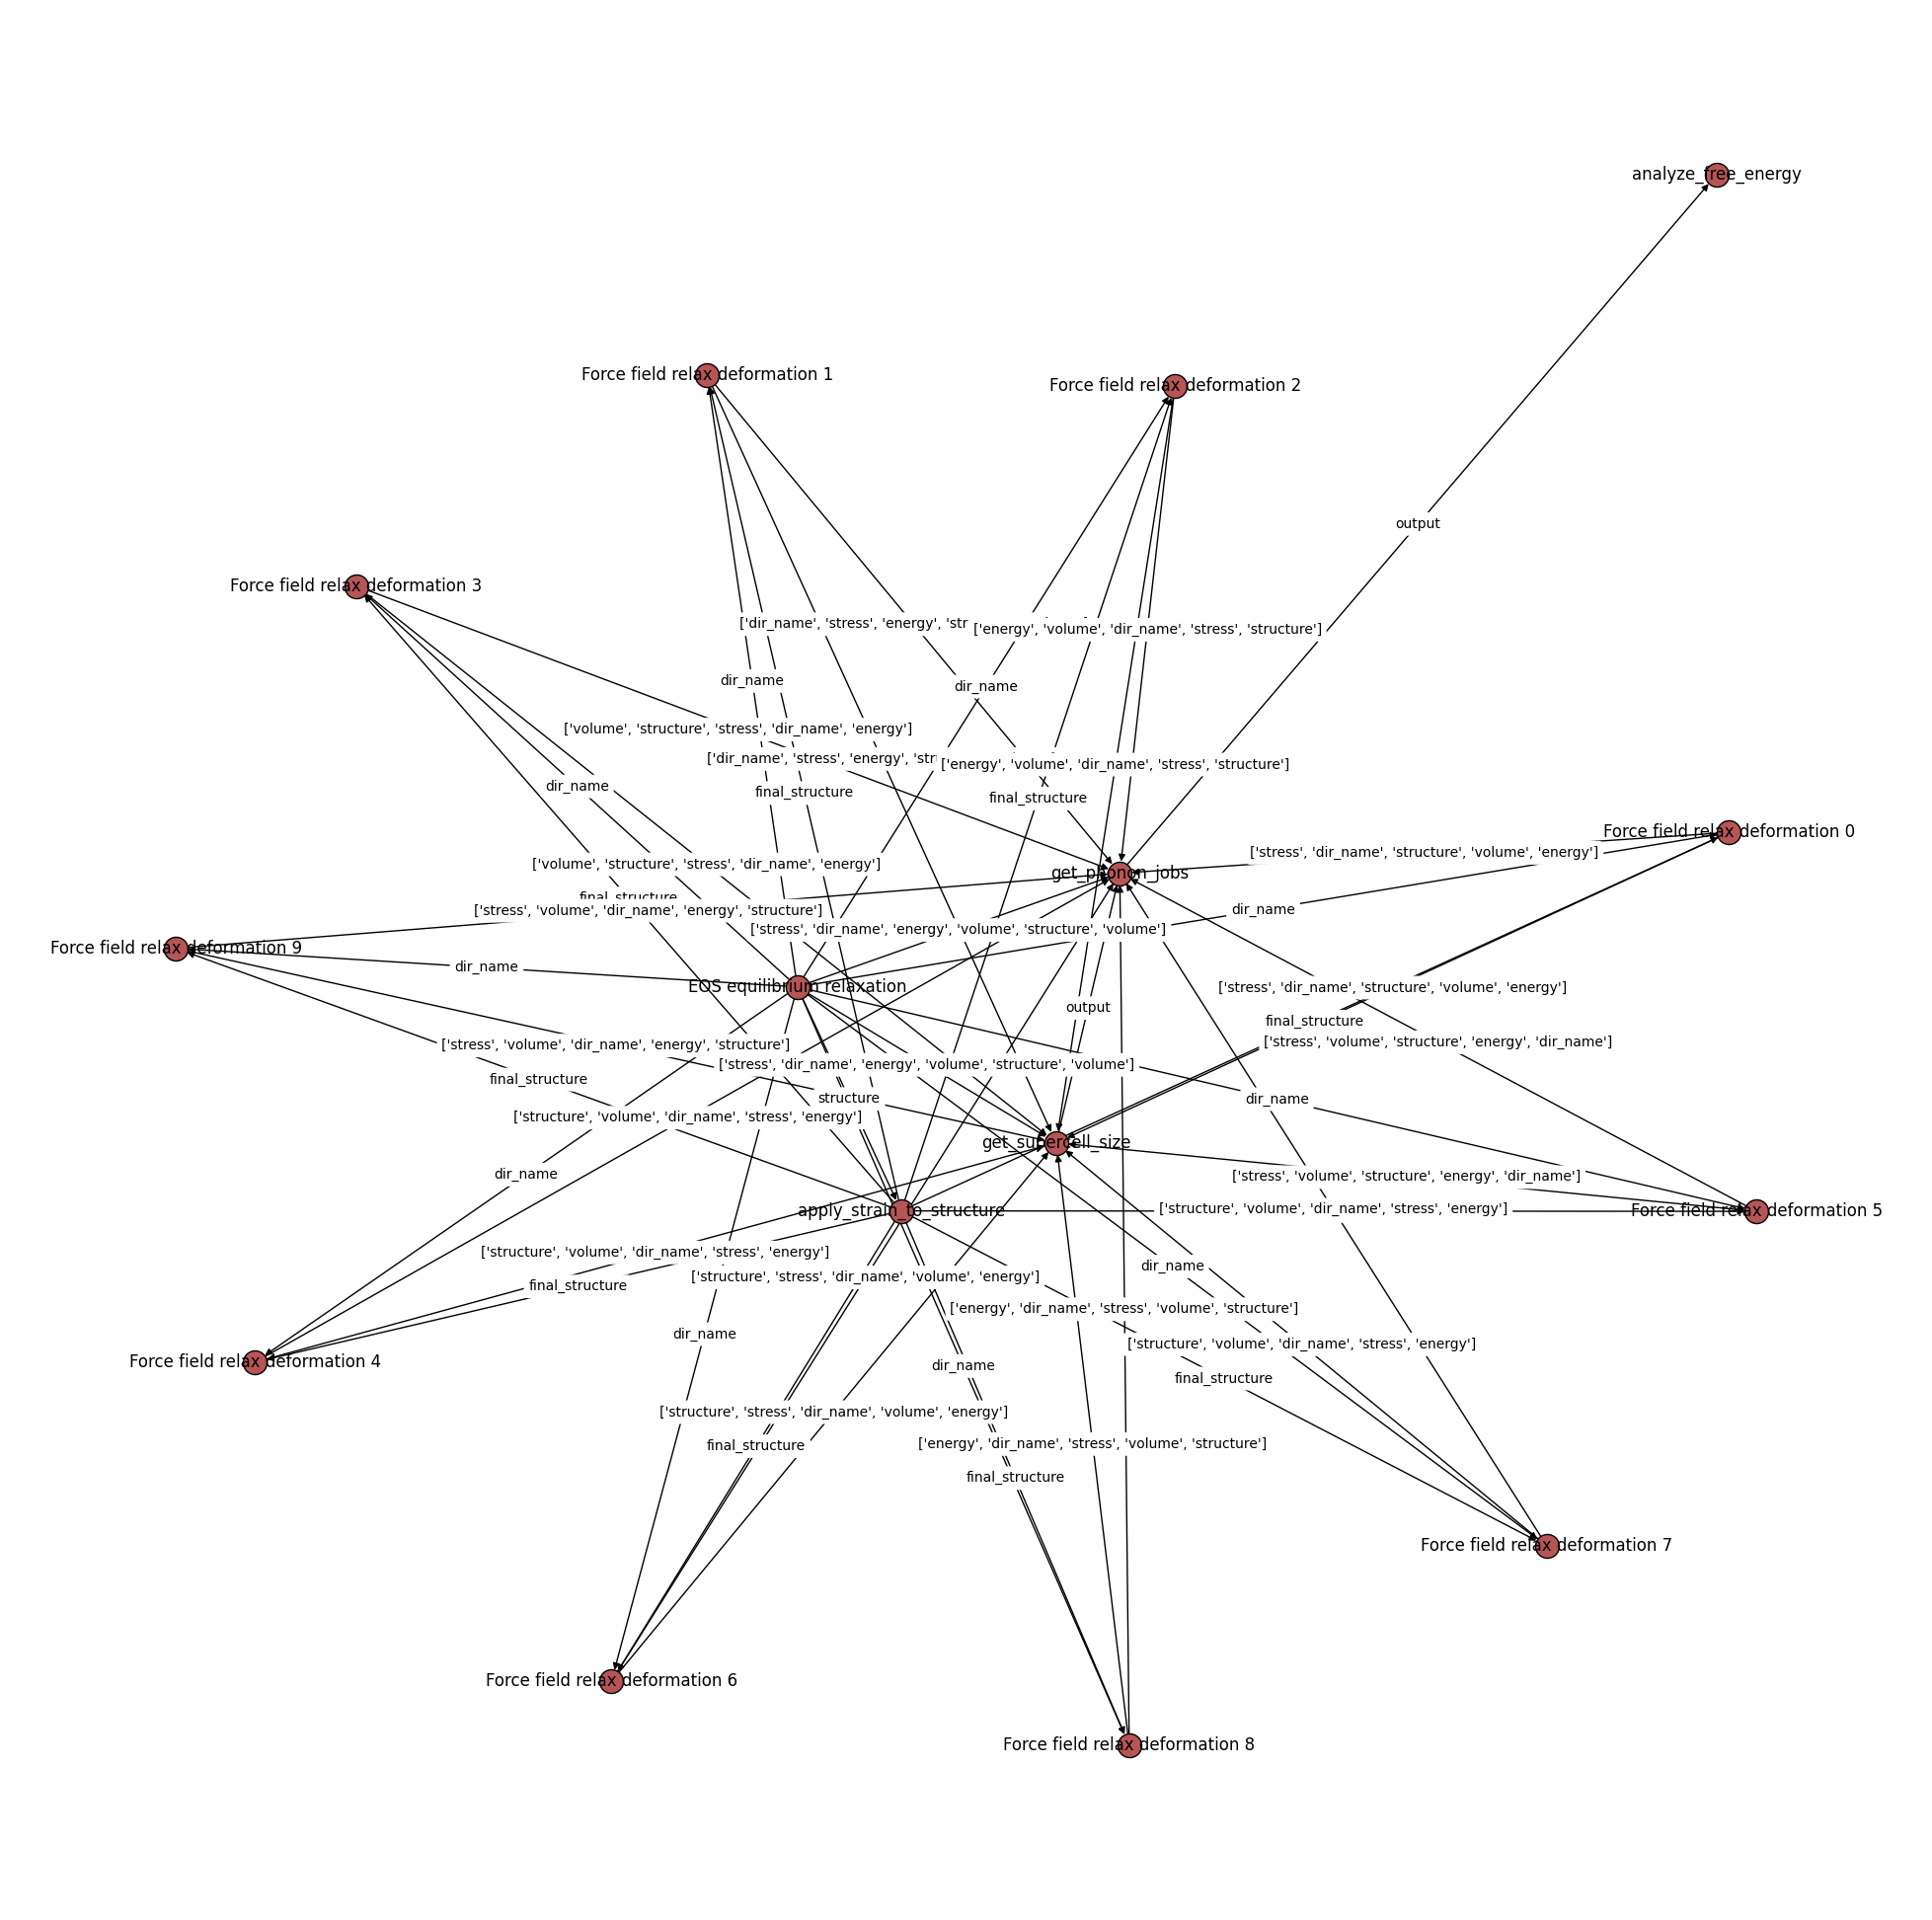

In [5]:
import networkx as nx
flow.draw_graph(figsize=(25, 25), layout_function=nx.nx_agraph.graphviz_layout).show()

In [ ]:
# PET-MAD universal potential
# Install: pip install pet-mad
# Docs / source: https://github.com/lab-cosmo/pet-mad
#
# PET-MAD is not in atomate2's MLFF enum, so we pass it via the monty-decodable
# dict mechanism supported by atomate2's ase_calculator() utility.
# calculator_kwargs are forwarded directly to PETMADCalculator(**kwargs).

pet_mad_calculator = {
    "@module": "pet_mad.calculator",
    "@callable": "PETMADCalculator",
}
pet_mad_kwargs = {"device": "cpu"}  # change to "cuda" on GPU nodes

bulk_relax_maker_petmad = ForceFieldRelaxMaker(
    force_field_name=pet_mad_calculator,
    relax_cell=True,
    relax_kwargs={"fmax": 0.0001},
    calculator_kwargs=pet_mad_kwargs,
)
bulk_relax_maker_petmad_cv = ForceFieldRelaxMaker(
    force_field_name=pet_mad_calculator,
    relax_cell=False,
    relax_kwargs={"fmax": 0.0001},
    calculator_kwargs=pet_mad_kwargs,
)

phonon_displacement_maker_petmad = ForceFieldStaticMaker(
    force_field_name=pet_mad_calculator,
    calculator_kwargs=pet_mad_kwargs,
)
phonon_displacement_maker_petmad.name = "pet-mad phonon static"

flow_petmad = QhaMaker(
    initial_relax_maker=bulk_relax_maker_petmad,
    eos_relax_maker=bulk_relax_maker_petmad_cv,
    min_length=10,
    phonon_maker=PhononMaker(
        generate_frequencies_eigenvectors_kwargs={
            "tmin": 0,
            "tmax": 500,
            "tstep": 10,
        },
        bulk_relax_maker=None,
        born_maker=None,
        static_energy_maker=phonon_displacement_maker_petmad,
        phonon_displacement_maker=phonon_displacement_maker_petmad,
    ),
    linear_strain=(-0.1, 0.1),
    number_of_frames=10,
    pressure=None,
    t_max=None,
    ignore_imaginary_modes=False,
    skip_analysis=False,
    eos_type="vinet",
).make(structure=si_structure)